In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# drive.mount('/content/drive')

df = pd.read_csv('/content/customer_churn_1M.csv')

df.head()

,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,53:58.2,43,Female,55085.25,college,married,1,2,two_year,...,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,CUST0000000002,53:58.2,18,Male,60786.11,master,married,1,22,one_year,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,CUST0000000003,53:58.2,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,CUST0000000004,53:58.2,44,Male,40923.78,high_school,married,1,6,two_year,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,CUST0000000005,53:58.2,45,Female,36400.94,bachelor,single,0,9,two_year,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (1000000, 32)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   customer_id                  1000000 non-null  object 
 1   signup_date                  1000000 non-null  object 
 2   age                          1000000 non-null  int64  
 3   gender                       1000000 non-null  object 
 4   annual_income                970041 non-null   float64
 5   education                    1000000 non-null  object 
 6   marital_status               1000000 non-null  object 
 7   dependents                   1000000 non-null  int64  
 8   tenure                       1000000 non-null  int64  
 9   contract                     1000000 non-null  object 
 10  payment_method               1000000 non-null  object 
 11  paperless_billing            1000000 non-null  object 
 12  senior_citizen               1000000 non-nu

In [ ]:
df.isnull().sum()


,0
customer_id,0
signup_date,0
age,0
gender,0
annual_income,29959
education,0
marital_status,0
dependents,0
tenure,0
contract,0


In [ ]:
# Missing values will be handled by the preprocessing pipeline.
# Do not impute them here, before the train-test split.

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Duplicate customer IDs:", df['customer_id'].duplicated().sum())

Duplicate customer IDs: 0


In [ ]:
df.nunique()

,0
customer_id,1000000
signup_date,69
age,73
gender,3
annual_income,856556
education,5
marital_status,4
dependents,6
tenure,72
contract,3


In [ ]:
print(df['signup_date'].head())
print(df['signup_date'].dtype)

0    53:58.2
1    53:58.2
2    53:58.2
3    53:58.2
4    53:58.2
Name: signup_date, dtype: object
object


In [ ]:
df['signup_date'] = pd.to_datetime(df['signup_date'])



/tmp/ipykernel_486/1807732673.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['signup_date'] = pd.to_datetime(df['signup_date'])


DateParseError: hour must be in 0..23: 53:58.2, at position 0

In [ ]:
df['signup_year'] = df['signup_date'].dt.year
df['signup_month'] = df['signup_date'].dt.month

In [ ]:
df[['signup_date', 'signup_year', 'signup_month']].head()

In [ ]:
df['signup_year'].value_counts().sort_index()

In [ ]:
df['signup_month'].value_counts().sort_index()

In [ ]:
print("Earliest signup date:", df['signup_date'].min())
print("Latest signup date:", df['signup_date'].max())

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

In [ ]:
df.describe().T

In [ ]:
q1 = df['monthlycharges'].quantile(0.25)
q3 = df['monthlycharges'].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[
    (df['monthlycharges'] < lower_bound) |
    (df['monthlycharges'] > upper_bound)
]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of potential outliers:", len(outliers))
print("Percentage:", round(len(outliers) / len(df) * 100, 2), "%")

In [ ]:
outliers['monthlycharges'].describe()

In [ ]:
df.nlargest(10, 'monthlycharges')[
    ['monthlycharges', 'totalcharges', 'tenure', 'num_services', 'churn']
]

In [ ]:
print(
    "Monthly charges above $200:",
    (df['monthlycharges'] > 200).sum()
)

print(
    "Percentage above $200:",
    round((df['monthlycharges'] > 200).mean() * 100, 3),
    "%"
)

In [ ]:
df.loc[
    df['monthlycharges'] > 200,
    ['monthlycharges', 'totalcharges', 'tenure', 'num_services', 'churn']
].describe()

In [ ]:
print(df['churn'].value_counts())
print("\nChurn percentage:")
print((df['churn'].value_counts(normalize=True) * 100).round(2))

In [ ]:
binary_cols = [
    'senior_citizen',
    'has_phone_service',
    'has_internet_service',
    'has_online_security',
    'has_online_backup',
    'has_device_protection',
    'has_tech_support',
    'has_streaming_tv',
    'has_streaming_movies',
    'paperless_billing',
    'churn'
]

for col in binary_cols:
    print(col, sorted(df[col].dropna().unique()))

In [ ]:
expected_total = df['monthlycharges'] * df['tenure']

difference_pct = (
    (df['totalcharges'] - expected_total).abs()
    / expected_total
) * 100

print("Within 10% difference:", (difference_pct <= 10).mean() * 100, "%")
print("Above 10% difference:", (difference_pct > 10).mean() * 100, "%")

In [ ]:
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df['customer_id'].duplicated().sum())
print("Invalid churn values:", (~df['churn'].isin([0, 1])).sum())
print("Signup date dtype:", df['signup_date'].dtype)

Dataset shape: (1000000, 32)
Missing values: 170193
Duplicate rows: 0
Duplicate customer IDs: 0
Invalid churn values: 0
Signup date dtype: object


In [ ]:

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separate features and target
X = df.drop(columns=["churn"])
y = df["churn"]

# Exclude identifiers and raw datetime from model features
excluded_cols = ["customer_id", "signup_date"]

X = X.drop(columns=excluded_cols)

# Identify column types
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

print("Preprocessing pipeline created successfully!")
print("Numerical columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("Total input features:", X.shape[1])


Preprocessing pipeline created successfully!
Numerical columns: 23
Categorical columns: 6
Total input features: 29


# logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",LogisticRegression(max_iter=1000,n_jobs=-1))
])
logistic_pipeline.fit(x_train,y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'annual_income',
                                                   'dependents', 'tenure',
                                                   'senior_citizen',
                                                   'monthlycharges',
                                                   'totalcharges',
                                                   'num_services',
                                                   'has_phone_service',
                                                   'has_internet_service',
                                                   'has_online_security',
                                                   'has_onlin...
                                                   'late_payments',
                                                   'avg_monthly_gb',
                                                   'days_since_last_interaction',
                                                   'credit_score']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'education',
                                                   'marital_status', 'contract',
                                                   'payment_method',
                                                   'paperless_billing'])])),
                ('model', LogisticRegression(max_iter=1000, n_jobs=-1))])

In [ ]:
y_pred=logistic_pipeline.predict(x_test)
y_prob = logistic_pipeline.predict_proba(x_test)[:,1]
y_prob

array([0.07884693, 0.09546682, 0.21401389, ..., 0.08913824, 0.0576358 ,
       0.0599245 ])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.90082
Precision: 0.5445544554455446
Recall: 0.002771478961955152
F1 Score: 0.005514890203549584
ROC-AUC: 0.6848568546335682


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95    180155
           1       0.54      0.00      0.01     19845

    accuracy                           0.90    200000
   macro avg       0.72      0.50      0.48    200000
weighted avg       0.87      0.90      0.85    200000



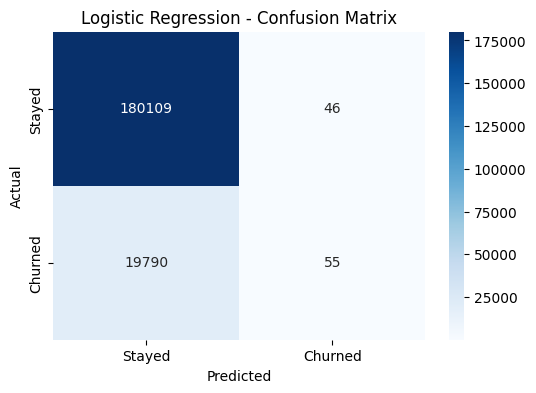

In [ ]:
cm = confusion_matrix(y_test, y_pred);
plt.figure(figsize=(6, 4));
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Stayed", "Churned"], yticklabels=["Stayed", "Churned"])
plt.xlabel("Predicted");
plt.ylabel("Actual");
plt.title("Logistic Regression - Confusion Matrix");
plt.show()

In [ ]:
results = x_test.copy()
results["churn_probability"] = y_prob
results["risk_category"] = pd.cut(results["churn_probability"],bins=[0, 0.4, 0.7, 1],labels=["Low", "Medium", "High"],include_lowest=True)



# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=10,min_samples_split=10,min_samples_leaf=5,random_state=42,class_weight="balanced"))
  ])

decision_tree_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'annual_income',
                                                   'dependents', 'tenure',
                                                   'senior_citizen',
                                                   'monthlycharges',
                                                   'totalcharges',
                                                   'num_services',
                                                   'has_phone_service',
                                                   'has_internet_service',
                                                   'has_online_security',
                                                   'has_onlin...
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'education',
                                                   'marital_status', 'contract',
                                                   'payment_method',
                                                   'paperless_billing'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=5,
                                        min_samples_split=10,
                                        random_state=42))])

In [ ]:
y_pred_dt = decision_tree_pipeline.predict(x_test)
y_prob_dt = decision_tree_pipeline.predict_proba(x_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Accuracy: 0.6099
Precision: 0.1510156090654957
Recall: 0.6342655580750819
F1 Score: 0.2439482915673392
ROC-AUC: 0.6656711244822012


In [ ]:
print(classification_report(y_test, y_pred_dt))

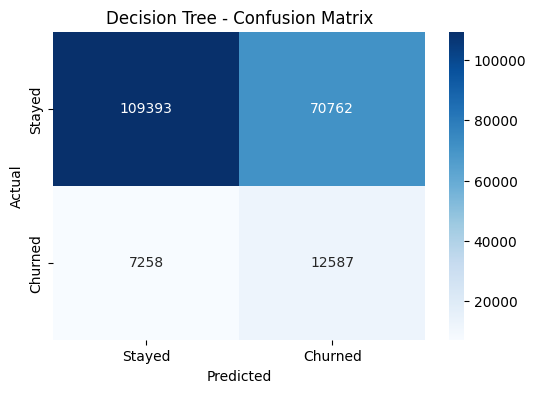

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt,annot=True,fmt="d",cmap="Blues",xticklabels=["Stayed", "Churned"],yticklabels=["Stayed", "Churned"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [ ]:
dt_results = x_test.copy()

dt_results["actual_churn"] = y_test.values
dt_results["churn_probability"] = y_prob_dt
dt_results["predicted_churn"] = y_pred_dt

dt_results["risk_category"] = pd.cut(dt_results["churn_probability"],bins=[0, 0.4, 0.7, 1],labels=["Low", "Medium", "High"],include_lowest=True)
dt_results.head()

,age,gender,annual_income,education,marital_status,dependents,tenure,contract,payment_method,paperless_billing,...,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,actual_churn,churn_probability,predicted_churn,risk_category
936629,50,Male,79928.29,master,married,1,11,two_year,bank_transfer,Yes,...,1.0,2,0,90.71,34,491.0,0,0.529982,1,Medium
572613,51,Male,68762.83,high_school,married,1,37,one_year,mailed_check,Yes,...,2.0,0,0,29.87,4,653.0,0,0.607070,1,Medium
872799,55,Female,72169.20,high_school,divorced,2,40,one_year,bank_transfer,Yes,...,2.0,2,0,0.00,6,686.0,0,0.525694,1,Medium
115894,50,Female,39593.46,master,single,0,5,one_year,bank_transfer,No,...,1.0,4,0,10.90,85,557.0,0,0.666272,1,Medium
85115,60,Male,58427.46,high_school,single,1,1,one_year,credit_card,Yes,...,1.0,6,0,27.18,27,532.0,0,0.392202,0,Low


In [ ]:
feature_names = decision_tree_pipeline.named_steps[
      "preprocessor"
      ].get_feature_names_out()
importances = decision_tree_pipeline.named_steps["model"].feature_importances_
feature_importance_dt = pd.DataFrame({
      "feature": feature_names,
      "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_dt.head(20)


In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(data=feature_importance_dt.head(15),x="importance",y="feature")

plt.title("Decision Tree - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
            n_estimators=10,
            max_depth=12,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
          ))
  ])

random_forest_pipeline.fit(x_train, y_train)

In [ ]:
y_pred_rf = random_forest_pipeline.predict(x_test)
y_prob_rf = random_forest_pipeline.predict_proba(x_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

In [ ]:
print(classification_report(y_test, y_pred_rf))

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
rf_results = x_test.copy()

rf_results["actual_churn"] = y_test.values
rf_results["churn_probability"] = y_prob_rf
rf_results["predicted_churn"] = y_pred_rf

rf_results["risk_category"] = pd.cut(rf_results["churn_probability"],bins=[0, 0.4, 0.7, 1],labels=["Low", "Medium", "High"],)

rf_results.head()

In [ ]:
feature_names_rf = random_forest_pipeline.named_steps[
      "preprocessor"
      ].get_feature_names_out()
importances_rf = random_forest_pipeline.named_steps[
      "model"
      ].feature_importances_
feature_importance_rf = pd.DataFrame({
      "feature": feature_names_rf,
          "importance": importances_rf
          }).sort_values("importance", ascending=False)
feature_importance_rf.head(20)

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(data=feature_importance_rf.head(15),x="importance",y="feature")

plt.title("Random Forest - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [ ]:
X_train_svm, _, y_train_svm, _ = train_test_split(x_train,y_train,train_size=100000,random_state=42)



In [ ]:
svm_pipeline = Pipeline([
      ("preprocessor", preprocessor),
      ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
])
svm_pipeline.fit(X_train_svm, y_train_svm)

In [ ]:
y_pred_svm = svm_pipeline.predict(x_test)
y_prob_svm = svm_pipeline.predict_proba(x_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

In [ ]:
print(classification_report(y_test, y_pred_svm))

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
    )

plt.xlabel("Predicted")
plt.title("SVM - Confusion Matrix")
plt.show()

In [ ]:
svm_results = x_test.copy()

svm_results["actual_churn"] = y_test.values
svm_results["churn_probability"] = y_prob_svm
svm_results["predicted_churn"] = y_pred_svm

svm_results["risk_category"] = pd.cut(
    svm_results["churn_probability"],bins=[0, 0.4, 0.7, 1],labels=["Low", "Medium", "High"],include_lowest=True
)



# XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
          n_estimators=200,
          max_depth=6,
          learning_rate=0.1,
          subsample=0.8,
          colsample_bytree=0.8,
          random_state=42,
          n_jobs=-1,
          eval_metric="logloss"
        ))
])
xgb_pipeline.fit(x_train, y_train)

y_pred_xgb = xgb_pipeline.predict(x_test)
y_prob_xgb = xgb_pipeline.predict_proba(x_test)[:, 1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.900665
Precision: 0.45089285714285715
Recall: 0.00508944318468128
F1 Score: 0.01006527480193333
ROC-AUC: 0.6830473185309431


In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95    180155
           1       0.45      0.01      0.01     19845

    accuracy                           0.90    200000
   macro avg       0.68      0.50      0.48    200000
weighted avg       0.86      0.90      0.85    200000



Text(0.5, 1.0, 'XGBoost - Confusion Matrix')

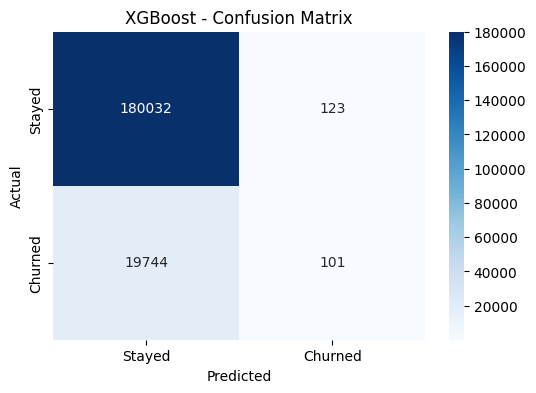

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
  )

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")

In [ ]:
feature_names_xgb = xgb_pipeline.named_steps[
      "preprocessor"
      ].get_feature_names_out()

importances_xgb = xgb_pipeline.named_steps["model"].feature_importances_
feature_importance_xgb = pd.DataFrame({
      "feature": feature_names_xgb,
      "importance": importances_xgb
}).sort_values("importance", ascending=False)

feature_importance_xgb.head(20)


,feature,importance
37,categorical__contract_two_year,0.459312
36,categorical__contract_one_year,0.113621
35,categorical__contract_month_to_month,0.070546
16,numeric__customer_satisfaction,0.045240
17,numeric__num_complaints,0.036992
13,numeric__has_tech_support,0.029964
18,numeric__num_service_calls,0.024020
10,numeric__has_online_security,0.018701
19,numeric__late_payments,0.018382
7,numeric__num_services,0.012567


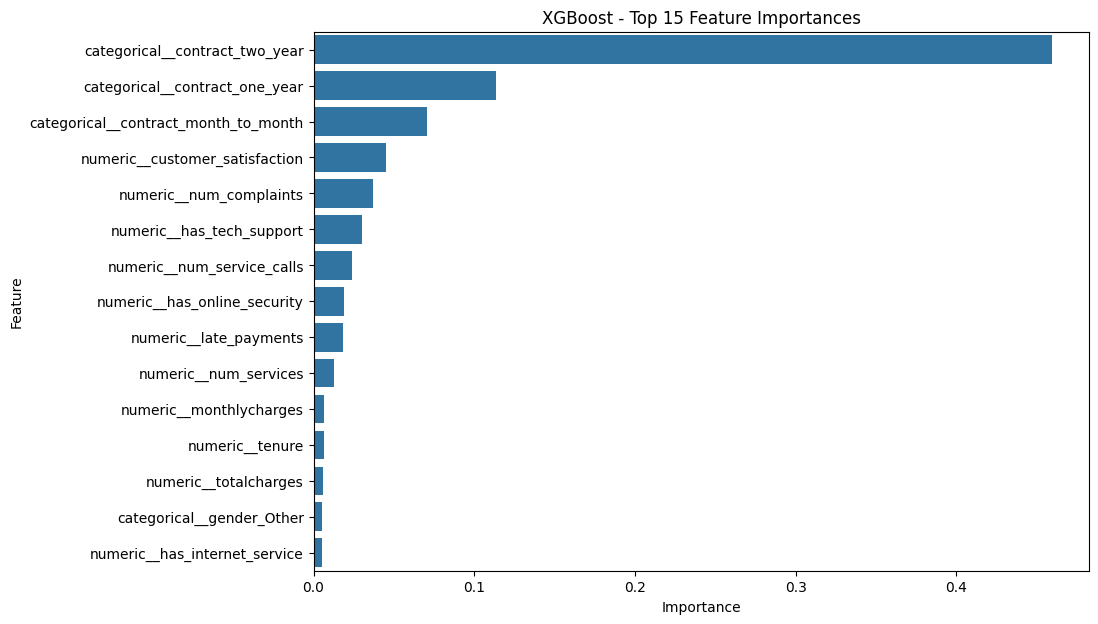

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_xgb.head(15),
        x="importance",
        y="feature"
  )

plt.title("XGBoost - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
xgb_results = x_test.copy()

xgb_results["actual_churn"] = y_test.values
xgb_results["churn_probability"] = y_prob_xgb
xgb_results["predicted_churn"] = y_pred_xgb

xgb_results["risk_category"] = pd.cut(
    xgb_results["churn_probability"],
    bins=[0, 0.4, 0.7, 1],
    labels=["Low", "Medium", "High"],
    include_lowest=True
  )
xgb_results.head()

,age,gender,annual_income,education,marital_status,dependents,tenure,contract,payment_method,paperless_billing,...,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,actual_churn,churn_probability,predicted_churn,risk_category
936629,50,Male,79928.29,master,married,1,11,two_year,bank_transfer,Yes,...,1.0,2,0,90.71,34,491.0,0,0.098216,0,Low
572613,51,Male,68762.83,high_school,married,1,37,one_year,mailed_check,Yes,...,2.0,0,0,29.87,4,653.0,0,0.086553,0,Low
872799,55,Female,72169.20,high_school,divorced,2,40,one_year,bank_transfer,Yes,...,2.0,2,0,0.00,6,686.0,0,0.163634,0,Low
115894,50,Female,39593.46,master,single,0,5,one_year,bank_transfer,No,...,1.0,4,0,10.90,85,557.0,0,0.233410,0,Low
85115,60,Male,58427.46,high_school,single,1,1,one_year,credit_card,Yes,...,1.0,6,0,27.18,27,532.0,0,0.102891,0,Low
